In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polatory as p
import polatory.three as p3

def variog(m: p3.Model, diff: np.ndarray) -> float:
    v = m.nugget
    for rbf in m.rbfs:
        v += rbf.evaluate(np.zeros(3)) - rbf.evaluate(diff)
    return v

def dip_azimuth(dip: float, dip_az: float) -> np.ndarray:
    dip = np.radians(dip)
    dip_az = np.radians(dip_az)
    return np.array([np.cos(dip) * np.sin(dip_az),
                     np.cos(dip) * np.cos(dip_az),
                     -np.sin(dip)])

In [2]:
data = pd.read_csv("data/zn_pc.csv")
points = data[["X", "Y", "Z"]].values
hole_ids = data["Hole ID"].values
values = data["zn_pc Values"].values
hids = np.unique(hole_ids)
hole_indices = np.array([np.where(hids == hid)[0][0] for hid in hole_ids])
set_ids = hole_indices % 2
data.describe()

,X,Y,Z,zn_pc Values
count,21908.000000,21908.000000,21908.000000,21908.000000
mean,10639.893065,100687.106440,417.374481,6.905967
std,119.975917,142.805284,83.559264,6.253061
min,10243.899906,100195.433428,-74.646258,0.000000
25%,10561.373154,100609.338629,379.135308,0.331000
50%,10639.737025,100698.668995,419.090431,6.769000
75%,10738.411138,100796.100982,465.060468,11.923000
max,10892.871972,101169.902714,656.596926,30.000000


In [3]:
directions = np.array(
    [
        [0.0,0.0,1.0],
        [0.10607892,0.32647735,0.9392336],
        [-0.27771825,0.20177411,0.9392336],
        [-0.18759248,0.57735026,0.79465449],
        [-0.55543649,0.40354821,0.72707576],
        [-0.44935754,0.73002559,0.51491791],
        [-0.72360682,0.52573109,0.44721359],
        [0.21215785,0.6529547,0.72707576],
        [-0.065560378,0.85472882,0.51491791],
        [0.2763932,0.85065079,0.44721359],
        [-0.27771825,-0.20177411,0.9392336],
        [-0.60706198,0.0,0.79465449],
        [-0.55543649,-0.40354821,0.72707576],
        [-0.83315468,-0.20177411,0.51491791],
        [-0.72360682,-0.52573109,0.44721359],
        [-0.83315468,0.20177411,0.51491791],
        [0.10607892,-0.32647735,0.9392336],
        [-0.18759248,-0.57735026,0.79465449],
        [0.21215785,-0.6529547,0.72707576],
        [-0.065560378,-0.85472882,0.51491791],
        [0.2763932,-0.85065079,0.44721359],
        [-0.44935754,-0.73002559,0.51491791],
        [0.34327862,0.0,0.9392336],
        [0.49112347,-0.3568221,0.79465449],
        [0.68655723,0.0,0.72707576],
        [0.79263616,-0.32647735,0.51491791],
        [0.89442718,0.0,0.44721359],
        [0.55543649,-0.6529547,0.51491791],
        [0.49112347,0.3568221,0.79465449],
        [0.55543649,0.6529547,0.51491791],
        [0.79263616,0.32647735,0.51491791],
        [0.10607892,0.97943211,0.17163931],
        [-0.30353099,0.93417233,0.18759248],
        [-0.66151541,0.73002559,0.17163931],
        [-0.89871508,0.40354821,0.17163931],
        [-0.98224694,0.0,0.18759248],
        [-0.89871508,-0.40354821,0.17163931],
        [-0.66151541,-0.73002559,0.17163931],
        [-0.30353099,-0.93417233,0.18759248],
        [0.10607892,-0.97943211,0.17163931],
        [0.48987609,-0.85472882,0.17163931],
        [0.79465449,-0.57735026,0.18759248],
        [0.96427548,-0.20177411,0.17163931],
        [0.96427548,0.20177411,0.17163931],
        [0.79465449,0.57735026,0.18759248],
        [0.48987609,0.85472882,0.17163931],
    ]
)

calc = p3.VariogramCalculator(lag_distance=5.0, num_lags=200)
calc.directions = directions
calc.angle_tolerance = np.radians(10.6)
variogs = calc.calculate(points, values)

In [5]:
cov1 = p3.CovSpherical([20.0, 60.0])
cov2 = p3.CovSpherical([20.0, 60.0])
covs = [cov1, cov2]
m = p3.Model(covs, poly_degree=-1)
# res = p3.cross_validation(m, points, values, set_ids, 1e-2)
# print("Residual before fitting:", np.linalg.norm(res))

best_fit = None
best_cost = float("inf")
for _ in range(10):
    weight = p.WeightFunction(exp_num_pairs=1.0, exp_distance=-2.0)
    fit = p3.VariogramFitting(variogs, m, weight)
    if fit.final_cost < best_cost:
        best_fit = fit
        best_cost = fit.final_cost

m = best_fit.model
# res = p3.cross_validation(m, points, values, set_ids, 1e-2)
# print("Residual after fitting:", np.linalg.norm(res))

print(m.description)

        Type       Psill       Major  Semi-major       Minor     Azimuth         Dip    Rotation
         nug      5.4517
         sph     22.2822    268.0126     93.3510     56.2758     74.7084     59.7432     68.2729
         sph     11.5752     15.5398     12.9654     11.1033     74.7084     59.7432     68.2729



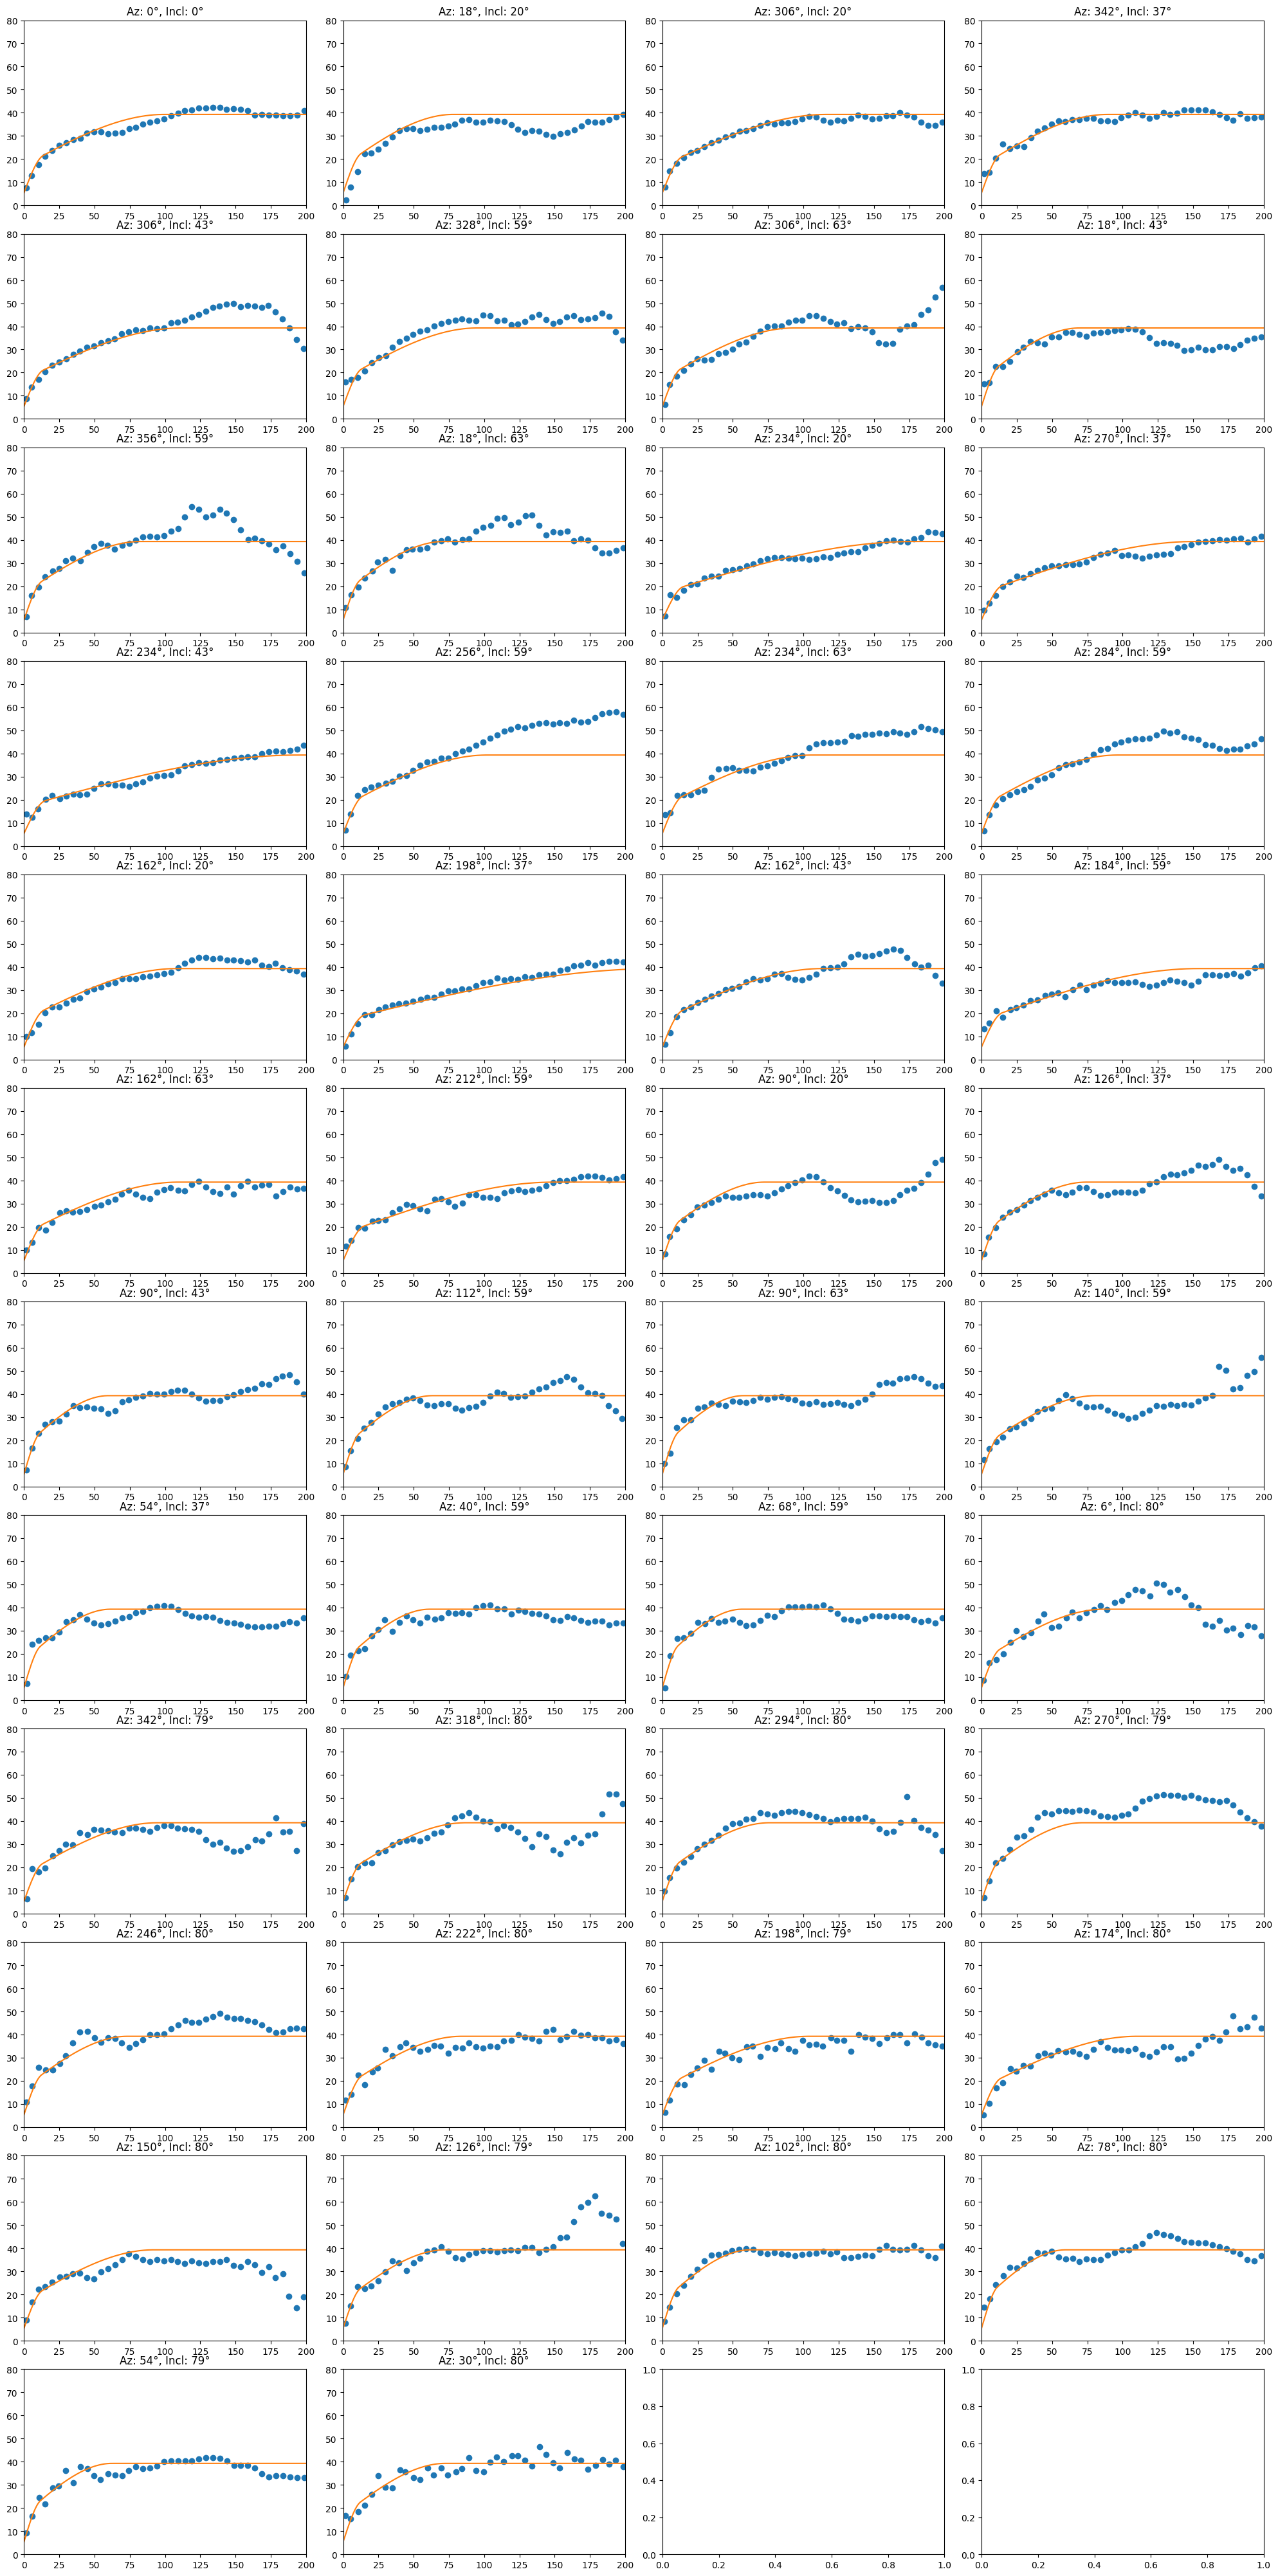

In [6]:
fig, ax = plt.subplots(nrows=12, ncols=4, figsize=(20, 40))
fig.tight_layout()
for i in range(12):
    for j in range(4):
        if 4 * i + j >= len(variogs):
            break
        v = variogs[4 * i + j]
        dir = v.direction
        az = np.degrees(np.arctan2(dir[0], dir[1]))
        if az < 0.0:
            az += 360.0
        incl = np.degrees(np.arccos(dir[2]))
        xs = np.linspace(0.0, 1000.0, 1000)
        ys = np.array([variog(m, x * dir) for x in xs])
        ax[i, j].plot(np.linalg.norm(v.bin_lag, axis=1), v.bin_gamma, "o")
        ax[i, j].plot(xs, ys, "-")
        ax[i, j].set_title(f"Az: {az:.0f}°, Incl: {incl:.0f}°")
        ax[i, j].set_xlim(0.0, 200.0)
        ax[i, j].set_ylim(0.0, 80)
        ax[i, j].margins(0.0)

In [ ]:
inter = p3.Interpolant(m)
inter.fit(points, values, absolute_tolerance=1e-3)

In [ ]:
fn = p.RbfFieldFunction(inter)
bbox = p3.Bbox.from_points(points)
iso = p.Isosurface(bbox, resolution=2.0)
surf = iso.generate(fn, isovalue=10.0)
surf.export_obj("data/zn_pc_10.obj")